## Importing and splitting data

In [63]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df=pd.read_csv('/Users/kishan/code/genai/ml/ml_learning/datasets/gld_price_data.csv')

In [65]:
df

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.1800,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.2850,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.1670,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.0530,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.5900,1.557099
...,...,...,...,...,...,...
2285,5/8/2018,2671.919922,124.589996,14.060000,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.370000,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.410000,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.380000,15.5600,1.193118


In [66]:
X= df.drop(['SLV','Date'], axis=1)
Y=df[['EUR/USD']]


In [67]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

# Standaization

In [68]:
scalar=StandardScaler()

In [69]:
X_train.shape
X_test.shape

(458, 4)

In [70]:
X_train_scaled=scalar.fit_transform(X_train,Y_train)
X_test_scaled=scalar.transform(X_test)

In [71]:
print(X.std())
print(X_train.std())
print(X_train_scaled.std())

SPX        519.111540
GLD         23.283346
USO         19.523517
EUR/USD      0.131547
dtype: float64
SPX        518.841801
GLD         23.247049
USO         19.695022
EUR/USD      0.131344
dtype: float64
1.0


In [72]:
X_train

,SPX,GLD,USO,EUR/USD
1018,1413.489990,160.539993,36.220001,1.253447
1870,2085.449951,120.900002,11.740000,1.132824
118,1245.359985,94.440002,109.250000,1.585590
220,805.219971,84.519997,28.660000,1.288494
2053,2328.949951,122.599998,11.130000,1.061639
...,...,...,...,...
1638,2095.840088,112.839996,19.660000,1.120787
1095,1426.189941,162.020004,33.369999,1.322769
1130,1502.420044,152.619995,33.430000,1.327316
1294,1807.229980,119.459999,33.189999,1.356779


In [73]:
pd.DataFrame(X_train_scaled)

,0,1,2,3
0,-0.479393,1.619523,0.221693,-0.229177
1,0.816076,-0.086105,-1.021600,-1.147799
2,-0.803530,-1.224625,3.930749,2.300308
3,-1.652074,-1.651462,-0.162265,0.037729
4,1.285519,-0.012957,-1.052581,-1.689919
...,...,...,...,...
1827,0.836107,-0.432910,-0.619358,-1.239469
1828,-0.454908,1.683205,0.076947,0.298755
1829,-0.307945,1.278742,0.079994,0.333384
1830,0.279697,-0.148065,0.067805,0.557764


## Effect of Scaling

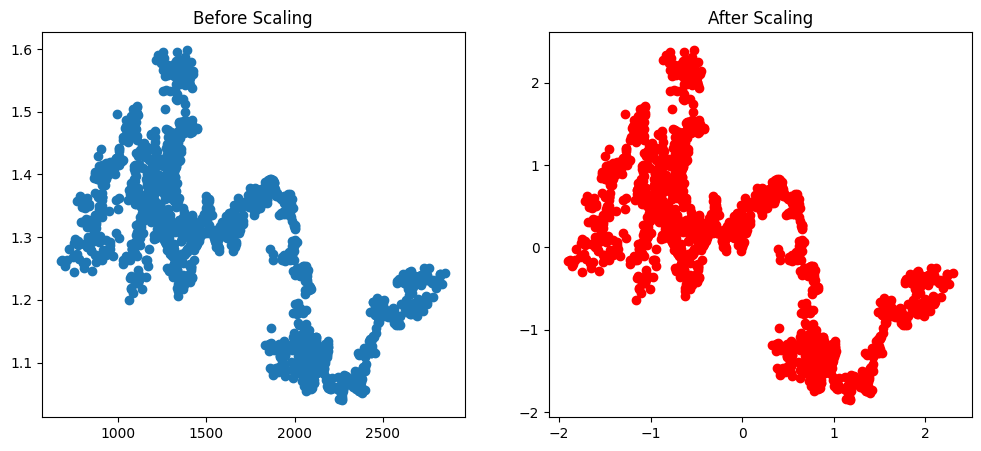

In [74]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scaling")
ax1.scatter(X_train['SPX'], X_train['EUR/USD'])

ax2.set_title("After Scaling")
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
ax2.scatter(X_train_scaled['SPX'], X_train_scaled['EUR/USD'],color='red')

plt.show()

<Axes: title={'center': 'After Standard Scaling'}, xlabel='SPX', ylabel='Density'>

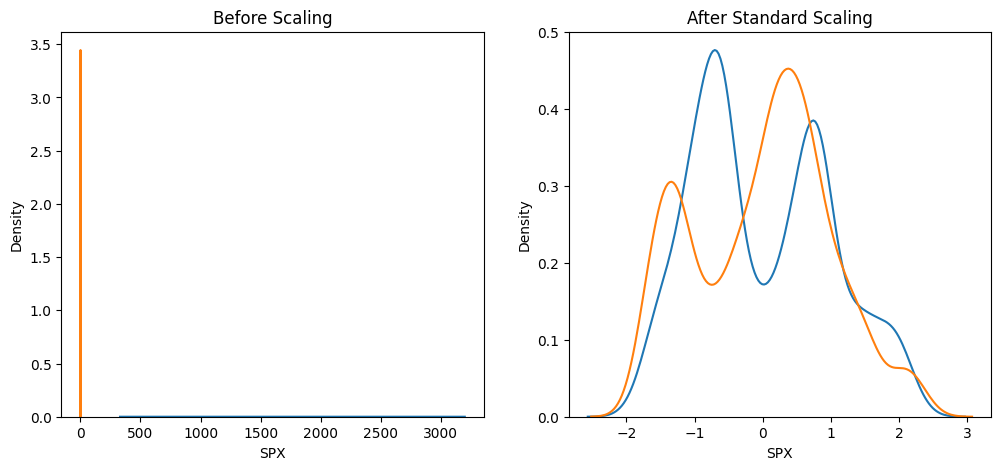

In [75]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['SPX'], ax=ax1)
sns.kdeplot(X_train['EUR/USD'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['SPX'], ax=ax2)
sns.kdeplot(X_train_scaled['EUR/USD'], ax=ax2)

# Check for Improvement

In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [81]:
lr = LinearRegression()
lr_scaled = LinearRegression()

In [82]:
lr.fit(X_train,Y_train)
lr_scaled.fit(X_train_scaled,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [83]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

/Users/kishan/.pyenv/versions/3.11.14/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [87]:
print("Actual",r2_score(Y_test,y_pred))
print("Scaled",r2_score(Y_test,y_pred_scaled))

Actual 1.0
Scaled 1.0


In [88]:
print("Actual",mean_absolute_error(Y_test,y_pred))
print("Scaled",mean_absolute_error(Y_test,y_pred_scaled))

Actual 4.416651421107064e-16
Scaled 5.4299117361579706e-17
